In [2]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\RAAID FARHAN\netflix_reviews.csv")
df.head()


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,01f38e3a-3725-436f-949a-a6a358e2435f,ㅎㅏ,I just signed in and downloaded only 14 episod...,2,0,9.70.1 build 7 64208,2026-06-20 09:11:19,9.70.1 build 7 64208
1,3ff30109-40be-46f6-b364-c901dc4d3037,Sekinat Abdulkareem,This app is so nice,5,0,9.62.0 build 8 64020,2026-06-20 09:10:49,9.62.0 build 8 64020
2,3ccc79c9-bf30-4dd3-81e5-0010dd9da705,Kumkum Chauhan,very worst app in my life I have ever seen eve...,1,0,NaN,2026-06-20 08:49:37,NaN
3,afb4b6a6-35e2-456f-80f9-b865e03d0051,Daimon -Sama,love stranger things,5,0,9.65.0 build 9 64092,2026-06-20 08:43:58,9.65.0 build 9 64092
4,c600c2c8-45c0-4a8b-a64c-89b0f2d754a9,Jay W,i want to uninstall. why can't I uninstall??,1,0,5.16.0 build 26728,2026-06-20 08:40:51,5.16.0 build 26728


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152593 entries, 0 to 152592
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              152593 non-null  object
 1   userName              152591 non-null  object
 2   content               152586 non-null  object
 3   score                 152593 non-null  int64 
 4   thumbsUpCount         152593 non-null  int64 
 5   reviewCreatedVersion  124813 non-null  object
 6   at                    152593 non-null  object
 7   appVersion            124813 non-null  object
dtypes: int64(2), object(6)
memory usage: 9.3+ MB


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (152593, 8)


In [5]:
df.isnull().sum()

reviewId                    0
userName                    2
content                     7
score                       0
thumbsUpCount               0
reviewCreatedVersion    27780
at                          0
appVersion              27780
dtype: int64

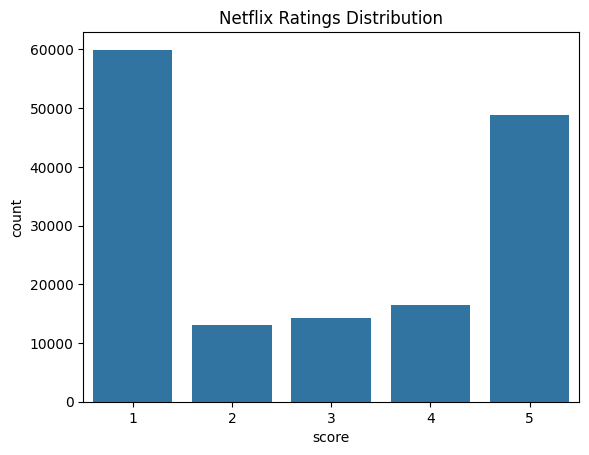

In [7]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.countplot(x='score', data = df)
plt.title("Netflix Ratings Distribution")
plt.show()

In [7]:
print("Average Rating:", round(df['score'].mean(),2))

Average Rating: 2.88


In [5]:
top_reviews = df.nlargest(10, 'thumbsUpCount')
[['userName','score','thumbsUpCount']]
top_reviews

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
58477,b47ea190-d298-4c49-a53b-0a724a9094a3,A Google user,Wow! To be able to have Netflix on my phone is...,5,8032,7.20.1 build 20 34387,2019-08-06 23:28:06,7.20.1 build 20 34387
56092,8a09072c-3d3d-4a31-8f33-4149d8590fc8,A Google user,"Watching NETFLIX right now, it always updates ...",5,7052,7.7.0 build 20 34181,2019-04-23 03:02:49,7.7.0 build 20 34181
49101,2ae57c89-2916-4f42-8afc-2d066fc6bfc1,bugby,Netflix has plenty of great shows and movies t...,3,6990,8.24.0 build 10 40205,2022-04-08 10:57:53,8.24.0 build 10 40205
49481,17bd0d68-3969-47ba-8447-4ced1fc2389d,A Google user,My only complaints are that there aren't enoug...,4,6558,7.11.1 build 29 34256,2019-06-01 05:03:14,7.11.1 build 29 34256
40084,8115bc9f-2b24-4568-a599-ca58488fcbc8,Gifty Mittal,Netflix is just awesome. I mean who wouldn't t...,4,4502,8.94.0 build 10 50546,2024-06-11 12:40:42,8.94.0 build 10 50546
49436,c6bae1b8-3112-4dd2-ad3f-aa628af33366,Auds Alcid,"I've been using this app for years but lately,...",2,4369,8.25.1 build 10 40215,2022-04-13 13:48:12,8.25.1 build 10 40215
50890,16136ee9-acf1-4c3b-940c-8bf43ba769b5,Rhonda V,"why do the subtitles automatically come on, wh...",4,4070,7.113.0 build 8 35543,2021-08-05 23:57:31,7.113.0 build 8 35543
49081,e0e98e41-a530-40b3-b6fb-4656e53f6e88,J C,I really love the app! There are a lot of good...,4,3935,8.73.0 build 11 50438,2023-06-16 09:39:55,8.73.0 build 11 50438
49281,8538276e-921f-4498-9f8d-64fe07f892a8,Erin Britz,Love Netflix and the ability to stream on my p...,2,3639,8.24.0 build 10 40205,2022-04-08 23:40:37,8.24.0 build 10 40205
49089,a7112c0f-c566-4d88-ac4c-9c8ce44272b6,Mike C,The minute I switched the service to include a...,1,3502,8.76.0 build 8 50457,2023-07-18 01:15:07,8.76.0 build 8 50457


Positive Reviews: 65202
Negative Reviews: 73084


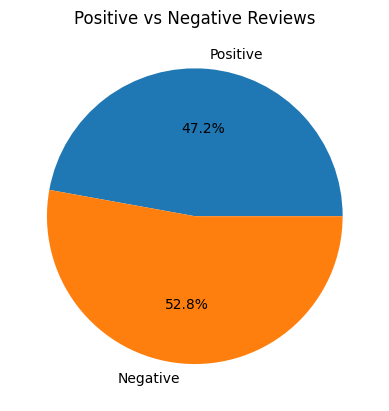

In [16]:
positive = len(df[df['score'] >= 4])
negative = len(df[df['score'] <= 2])

print("Positive Reviews:", positive)
print("Negative Reviews:", negative)

plt.pie(
    [positive, negative],
    labels=['Positive', 'Negative'],
    autopct='%1.1f%%'
)

plt.title("Positive vs Negative Reviews")
plt.show()

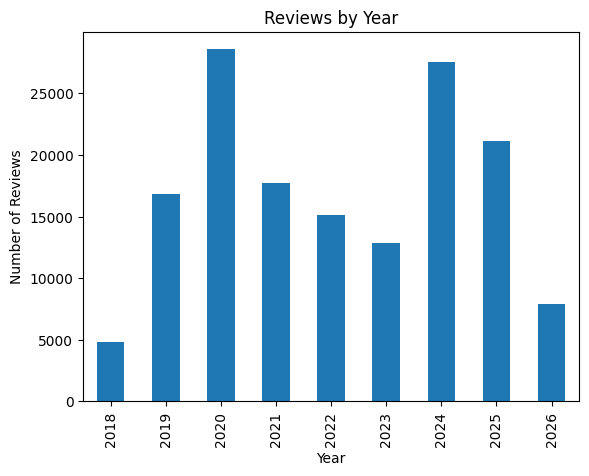

In [17]:
df['at'] = pd.to_datetime(df['at'])

df['year'] = df['at'].dt.year

df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

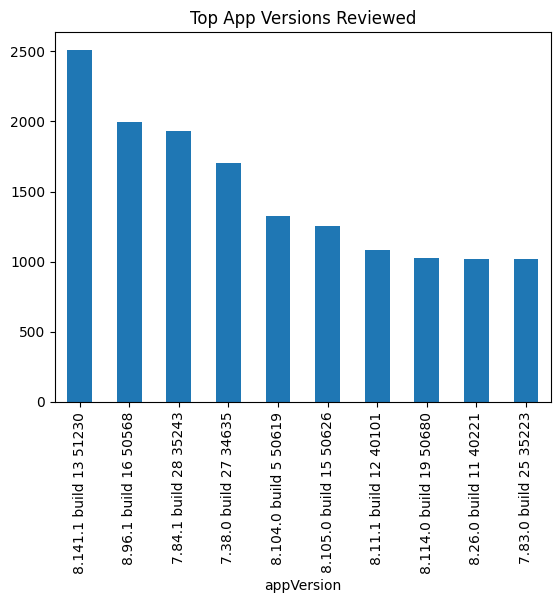

In [18]:
df['appVersion'].value_counts().head(10).plot(kind='bar')
plt.title("Top App Versions Reviewed")
plt.show()